In [19]:
import pandas as pd
# !pip install geopandas
import geopandas as gpd
import matplotlib.pyplot as plt
df = pd.read_csv("datasci112_final (1).csv")

In [27]:
df["FIPS"] = df["FIPS"].astype(str).str.zfill(5)
df["Disease_Burden"] = (
    df["% Adults with Obesity"] +
    df["% Adults with Diabetes"] +
    df["Cancer Incidence Rate"]
)

In [28]:
df['Median Household Income (Thousands)'] = df['Median household income'] / 1000

In [29]:
url = "https://www2.census.gov/geo/tiger/GENZ2018/shp/cb_2018_us_county_500k.zip"
counties = gpd.read_file(url)
ca_counties = counties[counties["STATEFP"] == "06"]
ca = ca_counties.merge(df, left_on="GEOID", right_on="FIPS")

In [30]:
def plot_map(gdf, column, title, reverse=False, flip_legend=False):
    fig, ax = plt.subplots(1,1,figsize=(8,8))
    cmap = "Reds_r" if reverse else "Reds"
    gdf.plot(
        column=column,
        linewidth=0.5,
        edgecolor="black",
        cmap=cmap,
        legend=True,
        ax=ax,
        missing_kwds={"color":"lightgrey"}
    )

    if flip_legend and len(fig.axes) > 1:
        cbar_ax = fig.axes[1]
        cbar_ax.invert_yaxis()

    ax.set_title(title)
    ax.axis("off")
    plt.show()

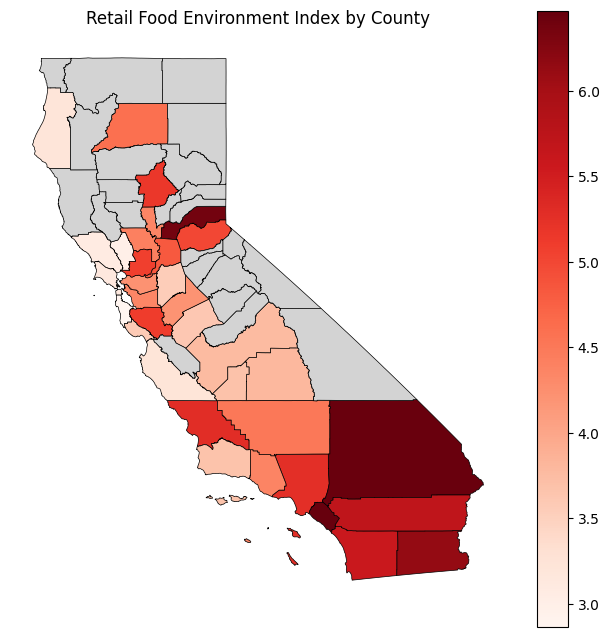

In [31]:
plot_map(
    ca,
    "Retail Food Environment Index",
    "Retail Food Environment Index by County"
)

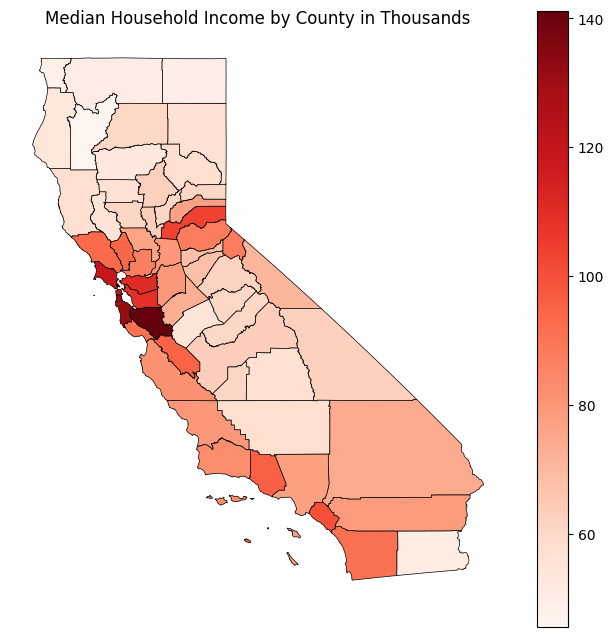

In [32]:
plot_map(
    ca,
    "Median Household Income (Thousands)",
    "Median Household Income by County in Thousands"
)

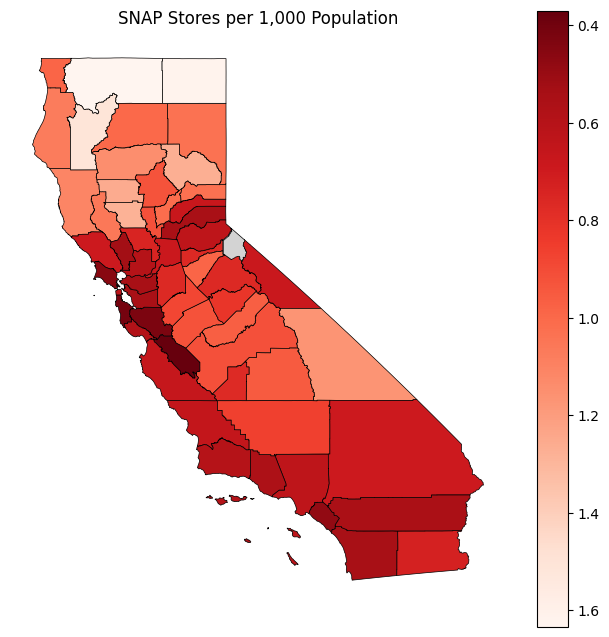

In [11]:
plot_map(
    ca,
    "SNAP-authorized stores/1,000 population",
    "SNAP Stores per 1,000 Population",
    reverse=True,
    flip_legend=True
)

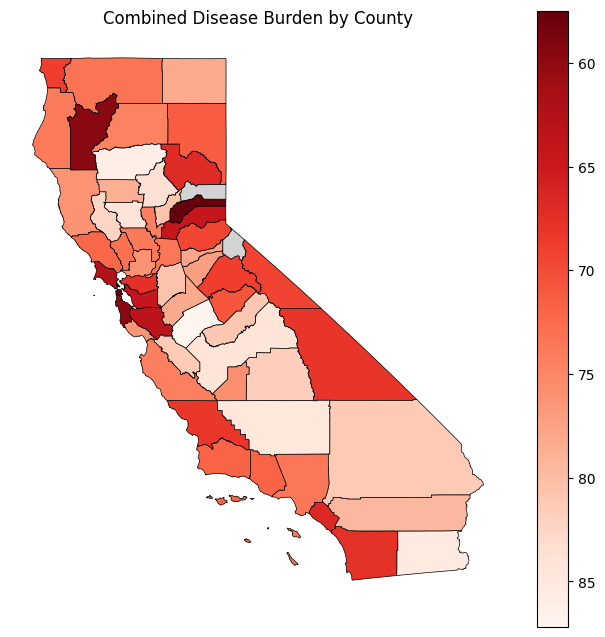

In [12]:
plot_map(
    ca,
    "Disease_Burden",
    "Combined Disease Burden by County",
    reverse=True,
    flip_legend=True
)